In [3]:
import gdsfactory as gf
gf.gpdk.PDK.activate()

Objective: Finalize the full die layout with test structures for fabrication.
Steps:
1. Integrate the wvl tracker layout with input/output connections.
2. Add test structures (e.g., waveguides, and mmis)
to enable characterization of the filter.
3. Export the final .GDS file for submission and verification

In [4]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

In [5]:
main = gf.Component()
die_ref = main << die(dieW = dieW, layer_box = "FLOORPLAN")

In [ ]:
gf.components.mmi2x2 #ctrl clic para acceder a la definición de mmi1x2 de gds factory y así pensar como hacer el 3x3

<function gdsfactory.components.mmis.mmi1x2.mmi1x2(width: 'float | None' = None, width_taper: 'float' = 1.0, length_taper: 'float' = 10.0, length_mmi: 'float' = 5.5, width_mmi: 'float' = 2.5, gap_mmi: 'float' = 0.25, taper: 'ComponentSpec' = <function taper at 0x748f080e6160>, straight: 'ComponentSpec' = <function straight at 0x748f07fa2660>, cross_section: 'CrossSectionSpec' = 'strip') -> 'Component'>

## DEFINICIÓN MMI3X3: basado en definición 2x2 gds

In [ ]:
from gdsfactory.component import Component
from gdsfactory.typings import CrossSectionSpec, ComponentSpec


@gf.cell
def mmi3x3(
    width: float | None = None,
    width_taper: float = 1.0,
    length_taper: float = 10.0,
    length_mmi: float = 20.0,
    width_mmi: float = 6.0,
    gap_mmi: float = 0.25,
    taper: ComponentSpec = gf.components.taper,
    straight: ComponentSpec = gf.components.straight,
    cross_section: CrossSectionSpec = "strip",
) -> Component:
    c = gf.Component()

    gap_mmi = gf.snap.snap_to_grid(gap_mmi, grid_factor=2)

    x = gf.get_cross_section(cross_section)
    width = width or x.width
    w_taper = width_taper

    _taper = gf.get_component(
        taper,
        length=length_taper,
        width1=width,
        width2=w_taper,
        cross_section=cross_section,
    )

    pitch = w_taper + gap_mmi

    y_bot = -pitch
    y_mid = 0
    y_top = +pitch

    _ = c << gf.get_component(
        straight,
        length=length_mmi,
        width=width_mmi,
        cross_section=cross_section,
    )

    temp_component = Component()

    ports = [
        temp_component.add_port(
            name="o1",
            orientation=180,
            center=(0, y_bot),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o2",
            orientation=180,
            center=(0, y_mid),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o3",
            orientation=180,
            center=(0, y_top),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o4",
            orientation=0,
            center=(length_mmi, y_top),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o5",
            orientation=0,
            center=(length_mmi, y_mid),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o6",
            orientation=0,
            center=(length_mmi, y_bot),
            width=w_taper,
            cross_section=x,
        ),
    ]

    for port in ports:
        taper_ref = c << _taper
        taper_ref.connect(
            port="o2",
            other=port,
            allow_width_mismatch=True,
        )
        c.add_port(name=port.name, port=taper_ref.ports["o1"])

    c.flatten()
    return c

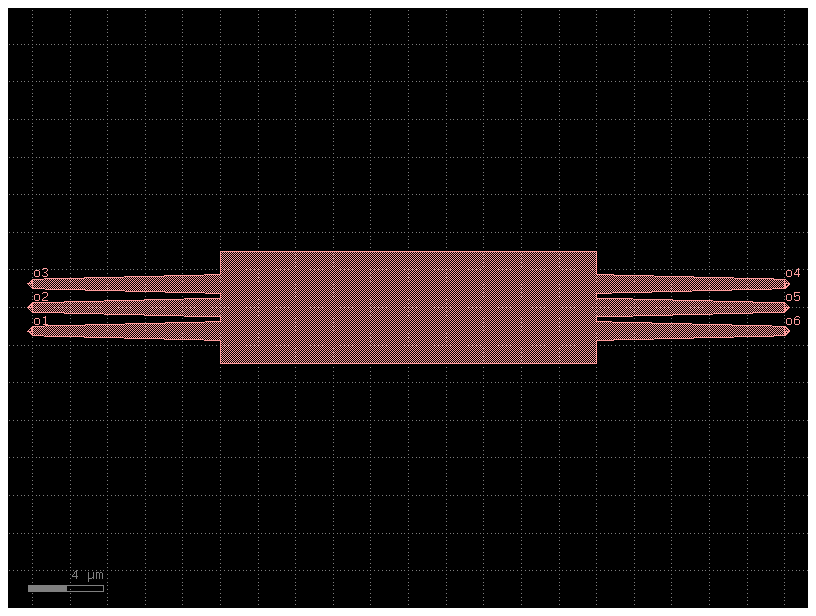

In [9]:
c = mmi3x3()
c.draw_ports()
c.plot()